In [1]:
import pandas as pd
data = []

In [2]:
# --- BUSINESS ---
for i in range(1, 511):  # you can adjust numbers based on number of files
    try:
        path = f"bbc news summary/News Articles/business/{i}.txt"
        with open(path, "r", encoding="latin-1") as f:
            data.append([f.read(), "business"])
    except FileNotFoundError:
        pass  # skip missing files

In [3]:
# --- ENTERTAINMENT ---
for i in range(1, 387):
    try:
        path = f"bbc news summary/News Articles/entertainment/{i}.txt"
        with open(path, "r", encoding="latin-1") as f:
            data.append([f.read(), "entertainment"])
    except FileNotFoundError:
        pass

In [4]:
# --- SPORT ---
for i in range(1, 512):
    try:
        path = f"bbc news summary/News Articles/sport/{i}.txt"
        with open(path, "r", encoding="latin-1") as f:
            data.append([f.read(), "sport"])
    except FileNotFoundError:
        pass

In [5]:
# --- TECH ---
for i in range(1, 402):
    try:
        path = f"bbc news summary/News Articles/tech/{i}.txt"
        with open(path, "r", encoding="latin-1") as f:
            data.append([f.read(), "tech"])
    except FileNotFoundError:
        pass

In [6]:
# --- POLITICS ---
for i in range(1, 418):
    try:
        path = f"bbc news summary/News Articles/politics/{i}.txt"
        with open(path, "r", encoding="latin-1") as f:
            data.append([f.read(), "politics"])
    except FileNotFoundError:
        pass

In [7]:
# Create DataFrame
df = pd.DataFrame(data, columns=["text", "category"])

# Display
print(df.head())
print("\nArticles per category:")
print(df["category"].value_counts())

                                                text  category
0  Ebbers denies WorldCom fraud\n\nFormer WorldCo...  business
1  Australia rates at four year high\n\nAustralia...  business
2  US company admits Benin bribery\n\nA US defenc...  business
3  US insurer Marsh cuts 2,500 jobs\n\nUp to 2,50...  business
4  US seeks new $280bn smoker ruling\n\nThe US Ju...  business

Articles per category:
category
sport            412
business         411
politics         318
tech             302
entertainment    287
Name: count, dtype: int64


In [8]:
import string, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = ''.join(ch for ch in text if ch not in string.punctuation and not ch.isdigit())
    words = nltk.word_tokenize(text)
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df["clean_text"] = df["text"].apply(preprocess_text)


In [9]:
df.head()

,text,category,clean_text
0,Ebbers denies WorldCom fraud\n\nFormer WorldCo...,business,ebbers denies worldcom fraud former worldcom c...
1,Australia rates at four year high\n\nAustralia...,business,australia rate four year high australia raisin...
2,US company admits Benin bribery\n\nA US defenc...,business,u company admits benin bribery u defence telec...
3,"US insurer Marsh cuts 2,500 jobs\n\nUp to 2,50...",business,u insurer marsh cut job job go u insurance bro...
4,US seeks new $280bn smoker ruling\n\nThe US Ju...,business,u seek new bn smoker ruling u justice departme...


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Create the vectorizer
bow_vectorizer = CountVectorizer(
    max_features=4000,     # limit number of words (optional)
    stop_words='english'   # remove common words
)

# Fit and transform the cleaned text
X_bow = bow_vectorizer.fit_transform(df["clean_text"])

print("Bag of Words matrix shape:", X_bow.shape)


Bag of Words matrix shape: (1730, 4000)


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=4000,     # limit number of features (optional)
    stop_words='english',  # remove stopwords
)

# Fit and transform the cleaned text
X = vectorizer.fit_transform(df["clean_text"])

# X is now a document-term matrix
print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (1730, 4000)


In [12]:
import pandas as pd

bow_features = bow_vectorizer.get_feature_names_out()
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_features)

print(df_bow.head())


   abandoned  abbas  abc  ability  able  abn  abortion  abroad  absence  \
0          0      0    0        0     0    0         0       0        0   
1          0      0    0        0     0    0         0       0        0   
2          0      0    0        0     0    0         0       0        0   
3          0      0    0        0     0    0         0       0        0   
4          0      0    0        0     0    0         0       0        0   

   absolute  ...  youve  yuan  yugansk  yuganskneftegas  yukos  yushchenko  \
0         0  ...      0     0        0                0      0           0   
1         0  ...      0     0        0                0      0           0   
2         0  ...      0     0        0                0      0           0   
3         0  ...      0     0        0                0      0           0   
4         0  ...      0     0        0                0      0           0   

   zealand  zero  zone  zurich  
0        0     0     0       0  
1        0    

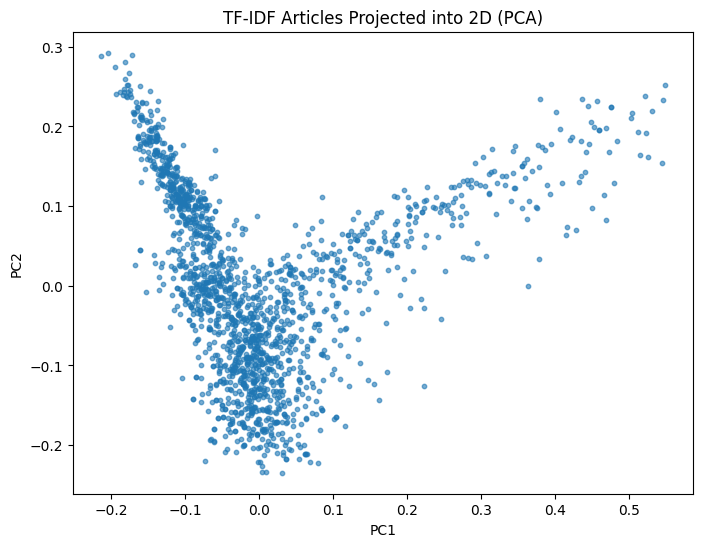

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6)
plt.title("TF-IDF Articles Projected into 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [14]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
X_norm = normalize(X)

In [15]:
from sklearn.preprocessing import LabelEncoder

# Convert text labels to numeric labels
le = LabelEncoder()
y_true = le.fit_transform(df["category"])


In [16]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure
from sklearn.metrics import pairwise_distances

k = 5   # ← change to the number of clusters you are using
X_norm = normalize(X)
# -------------------- K-MEANS --------------------
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_norm)

ari_k = adjusted_rand_score(y_true, kmeans_labels)
nmi_k = normalized_mutual_info_score(y_true, kmeans_labels)
h_k, c_k, v_k = homogeneity_completeness_v_measure(y_true, kmeans_labels)

print("\nK-Means Clustering Scores:")
print(f"ARI: {ari_k}")
print(f"NMI: {nmi_k}")
print(f"Homogeneity: {h_k}")
print(f"Completeness: {c_k}")
print(f"V-Measure: {v_k}")



K-Means Clustering Scores:
ARI: 0.6389799032059299
NMI: 0.6894358998330057
Homogeneity: 0.6669451808466336
Completeness: 0.7134964192334021
V-Measure: 0.6894358998330058


In [17]:
# -------------------- AGGLOMERATIVE --------------------
agg = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
agg_labels = agg.fit_predict(X.toarray())  # Agglo needs dense array

ari_a = adjusted_rand_score(y_true, agg_labels)
nmi_a = normalized_mutual_info_score(y_true, agg_labels)
h_a, c_a, v_a = homogeneity_completeness_v_measure(y_true, agg_labels)

print("\nAgglomerative Clustering Scores:")
print(f"ARI: {ari_a}")
print(f"NMI: {nmi_a}")
print(f"Homogeneity: {h_a}")
print(f"Completeness: {c_a}")
print(f"V-Measure: {v_a}")


Agglomerative Clustering Scores:
ARI: 0.5301320656673628
NMI: 0.6070585080555987
Homogeneity: 0.5130227373251013
Completeness: 0.7433043086051603
V-Measure: 0.6070585080555988


In [18]:
# -------------------- DBSCAN (Cosine) --------------------
# Convert to cosine distance matrix
distance_matrix = pairwise_distances(X, metric='cosine')

dbscan = DBSCAN(eps=0.7, min_samples=5, metric='precomputed')
db_labels = dbscan.fit_predict(distance_matrix)

# Remove noise points (-1) for fair eval
mask = (db_labels != -1)
true_db = y_true[mask]
pred_db = db_labels[mask]

if len(set(pred_db)) > 1:
    ari_d = adjusted_rand_score(true_db, pred_db)
    nmi_d = normalized_mutual_info_score(true_db, pred_db)
    h_d, c_d, v_d = homogeneity_completeness_v_measure(true_db, pred_db)

    print("\nDBSCAN Clustering Scores:")
    print(f"ARI: {ari_d}")
    print(f"NMI: {nmi_d}")
    print(f"Homogeneity: {h_d}")
    print(f"Completeness: {c_d}")
    print(f"V-Measure: {v_d}")

else:
    print("\nDBSCAN did not form multiple clusters (all noise or 1 cluster). Try changing eps.")


DBSCAN Clustering Scores:
ARI: 0.4457496243896452
NMI: 0.6158479396960317
Homogeneity: 0.6460624725138259
Completeness: 0.5883332413726838
V-Measure: 0.6158479396960318


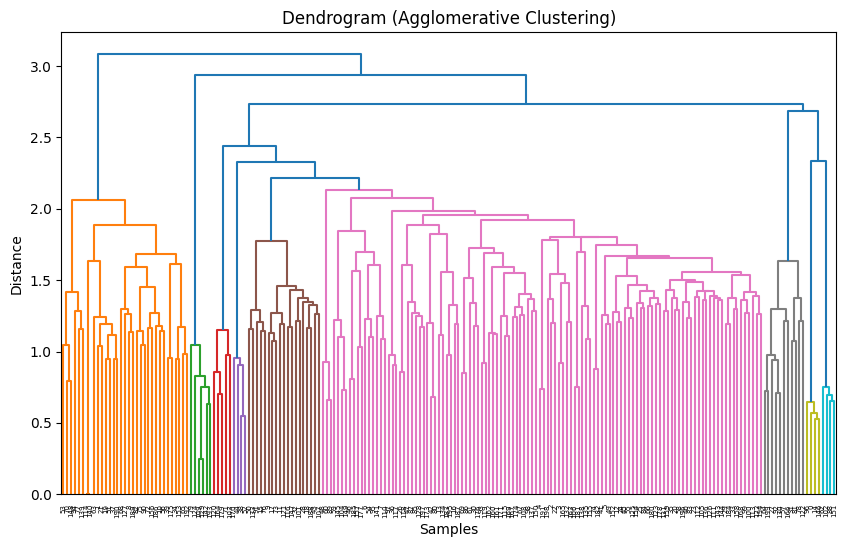

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Convert TF-IDF to dense for dendrogram
dense_data = X.toarray()

Z = linkage(dense_data[:200], method='ward')  # 200 samples to avoid heavy computation

plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Dendrogram (Agglomerative Clustering)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np

def clustering_precision_recall_f1(true_labels, pred_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    
    # Hungarian matching to align cluster labels to true labels
    row_ind, col_ind = linear_sum_assignment(-cm)
    cm = cm[:, col_ind]

    precision = np.diag(cm).sum() / cm.sum()                   # micro precision
    recall = np.diag(cm).sum() / cm.sum()                      # micro recall (same as precision in clustering)
    f1 = 2 * precision * recall / (precision + recall + 1e-10) # micro F1
    
    return precision, recall, f1


In [21]:
prec_k, rec_k, f1_k = clustering_precision_recall_f1(y_true, kmeans_labels)

print("\nK-Means Precision / Recall / F1:")
print(f"Precision: {prec_k:.4f}")
print(f"Recall: {rec_k:.4f}")
print(f"F1-Measure: {f1_k:.4f}")


K-Means Precision / Recall / F1:
Precision: 0.7312
Recall: 0.7312
F1-Measure: 0.7312


In [22]:
prec_a, rec_a, f1_a = clustering_precision_recall_f1(y_true, agg_labels)

print("\nAgglomerative Precision / Recall / F1:")
print(f"Precision: {prec_a:.4f}")
print(f"Recall: {rec_a:.4f}")
print(f"F1-Measure: {f1_a:.4f}")


Agglomerative Precision / Recall / F1:
Precision: 0.6075
Recall: 0.6075
F1-Measure: 0.6075


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_true = le.fit_transform(df["category"])   # numeric labels for all algorithms

# Remove noise for DBSCAN
mask = (db_labels != -1)

true_db = y_true[mask]
pred_db = db_labels[mask]

# Ensure pred_db is also mapped to 0...k-1
# (DBSCAN cluster numbers may be like: 3, 6, 9 → we remap them)
unique_labels = np.unique(pred_db)
label_map = {old:new for new, old in enumerate(unique_labels)}
pred_db_mapped = np.array([label_map[l] for l in pred_db])

if len(set(pred_db_mapped)) > 1:
    prec_d, rec_d, f1_d = clustering_precision_recall_f1(true_db, pred_db_mapped)

    print("\nDBSCAN Precision / Recall / F1:")
    print(f"Precision: {prec_d:.4f}")
    print(f"Recall: {rec_d:.4f}")
    print(f"F1-Measure: {f1_d:.4f}")
else:
    print("\nDBSCAN did not form meaningful clusters (only 1 cluster or noise).")



DBSCAN Precision / Recall / F1:
Precision: 0.4933
Recall: 0.4933
F1-Measure: 0.4933


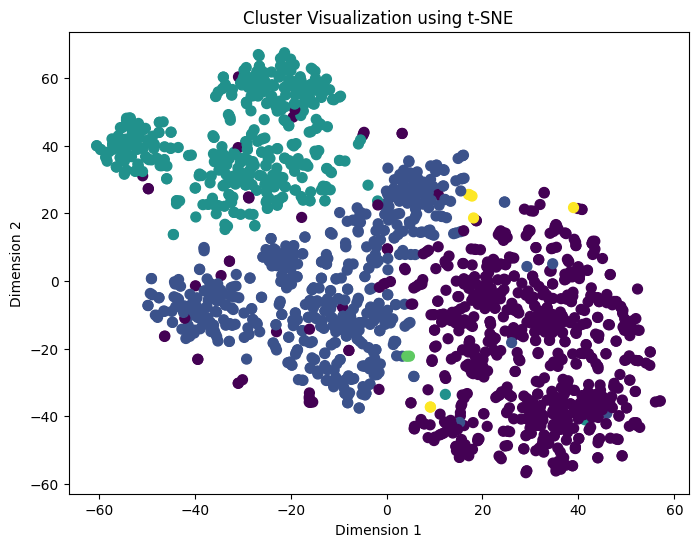

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Use the k-means / agglomerative / dbscan labels you computed earlier
labels = agg_labels  # or pred_km, pred_db

# Reduce TF-IDF features to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, s=50)
plt.title("Cluster Visualization using t-SNE")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


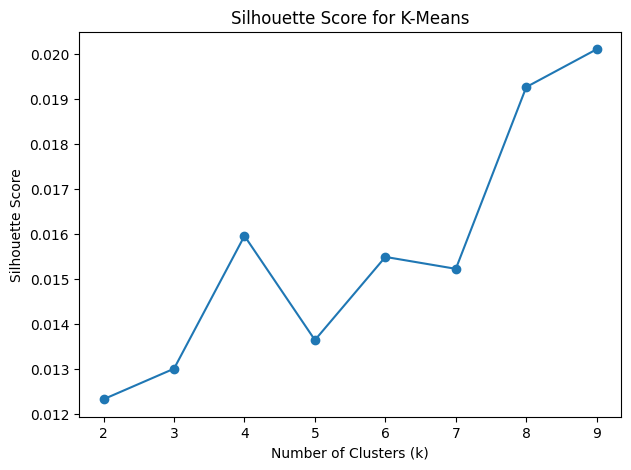

In [25]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

sil_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    sil_scores.append(silhouette_score(X, km.labels_))

plt.figure(figsize=(7,5))
plt.plot(K, sil_scores, marker="o")
plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


In [26]:
import numpy as np

def top_terms_per_cluster(model, tfidf, feature_names, n_terms=10):
    for i, center in enumerate(model.cluster_centers_):
        top_idxs = center.argsort()[::-1][:n_terms]
        top_words = [feature_names[j] for j in top_idxs]
        print(f"\nCluster {i} Top Terms:")
        print(", ".join(top_words))

from sklearn.feature_extraction.text import TfidfVectorizer
feature_names = vectorizer.get_feature_names_out()

top_terms_per_cluster(kmeans, X, feature_names, 10)   # K-Means example



Cluster 0 Top Terms:
film, music, award, said, tv, band, star, album, best, year

Cluster 1 Top Terms:
mr, said, lord, government, party, minister, eu, blair, police, mp

Cluster 2 Top Terms:
said, bn, firm, company, year, market, bank, share, price, growth

Cluster 3 Top Terms:
game, england, player, match, win, cup, said, club, play, injury

Cluster 4 Top Terms:
labour, mr, election, brown, blair, tax, party, tory, howard, chancellor


In [27]:
import numpy as np

def print_top_terms(cluster_labels, X, feature_names, n_terms=10):
    unique_clusters = np.unique(cluster_labels)
    for cluster in unique_clusters:
        if cluster == -1:
            continue  # skip DBSCAN noise
        # Select documents belonging to cluster
        cluster_docs = X[cluster_labels == cluster]
        # Average TF-IDF values across docs
        mean_tfidf = np.mean(cluster_docs.toarray(), axis=0)
        # Get top terms
        top_idxs = mean_tfidf.argsort()[::-1][:n_terms]
        top_words = [feature_names[i] for i in top_idxs]
        print(f"\nCluster {cluster} Top Terms:")
        print(", ".join(top_words))


In [28]:
print("\n==== Top Terms for K-Means ====")
print_top_terms(kmeans_labels, X, feature_names, 10)


==== Top Terms for K-Means ====

Cluster 0 Top Terms:
film, music, award, said, tv, band, star, album, best, year

Cluster 1 Top Terms:
mr, said, lord, government, party, minister, eu, blair, police, mp

Cluster 2 Top Terms:
said, bn, firm, company, year, market, bank, share, price, growth

Cluster 3 Top Terms:
game, england, player, match, win, cup, said, club, play, injury

Cluster 4 Top Terms:
labour, mr, election, brown, blair, tax, party, tory, howard, chancellor


In [29]:
print("\n==== Top Terms for Agglomerative Clustering ====")
print_top_terms(agg_labels, X, feature_names, 10)



==== Top Terms for Agglomerative Clustering ====

Cluster 0 Top Terms:
said, mr, bn, labour, election, government, party, year, blair, tax

Cluster 1 Top Terms:
film, music, said, people, game, award, year, mobile, technology, phone

Cluster 2 Top Terms:
game, england, player, club, win, match, said, cup, play, injury

Cluster 3 Top Terms:
sun, grid, brewer, computing, russian, employ, stake, august, hour, bought

Cluster 4 Top Terms:
csi, murder, sentence, forensic, betting, guilty, crime, episode, plea, blake


In [30]:
print("\n==== Top Terms for DBSCAN ====")
if len(set(db_labels)) > 1:
    print_top_terms(db_labels, X, feature_names, 10)
else:
    print("DBSCAN did not form clusters (only noise or 1 cluster).")



==== Top Terms for DBSCAN ====

Cluster 0 Top Terms:
ebbers, fraud, worldcom, sullivan, mr, trial, accounting, prosecutor, conspiracy, guilty

Cluster 1 Top Terms:
mr, said, labour, election, party, blair, tax, government, brown, tory

Cluster 2 Top Terms:
euro, profit, sale, mercedes, bn, brand, europe, year, western, said

Cluster 3 Top Terms:
airline, india, air, delta, jet, airway, share, carrier, aircraft, indian

Cluster 4 Top Terms:
gm, fiat, car, motor, engine, loss, bn, european, profit, auto

Cluster 5 Top Terms:
mci, qwest, att, verizon, bn, phone, worldcom, takeover, shareholder, company

Cluster 6 Top Terms:
lse, deutsche, boerse, euronext, bid, exchange, shareholder, stock, london, offer

Cluster 7 Top Terms:
glazer, club, united, mr, bid, manchester, proposal, board, magnier, mcmanus

Cluster 8 Top Terms:
film, music, award, said, mobile, phone, game, people, best, band

Cluster 9 Top Terms:
japan, rugby, japanese, host, hong, world, kong, cup, football, south

Cluster 

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_terms(cluster_labels, X, feature_names, n_terms=10):
    unique_clusters = np.unique(cluster_labels)

    for cluster in unique_clusters:
        if cluster == -1:
            continue  # skip DBSCAN noise

        cluster_docs = X[cluster_labels == cluster]
        mean_tfidf = np.mean(cluster_docs.toarray(), axis=0)
        top_idxs = mean_tfidf.argsort()[::-1][:n_terms]
        top_scores = mean_tfidf[top_idxs]
        top_words = [feature_names[i] for i in top_idxs]

        plt.figure(figsize=(10,4))
        plt.bar(top_words, top_scores)
        plt.xticks(rotation=45)
        plt.title(f"Top Terms for Cluster {cluster}")
        plt.xlabel("Terms")
        plt.ylabel("Average TF-IDF Score")
        plt.show()


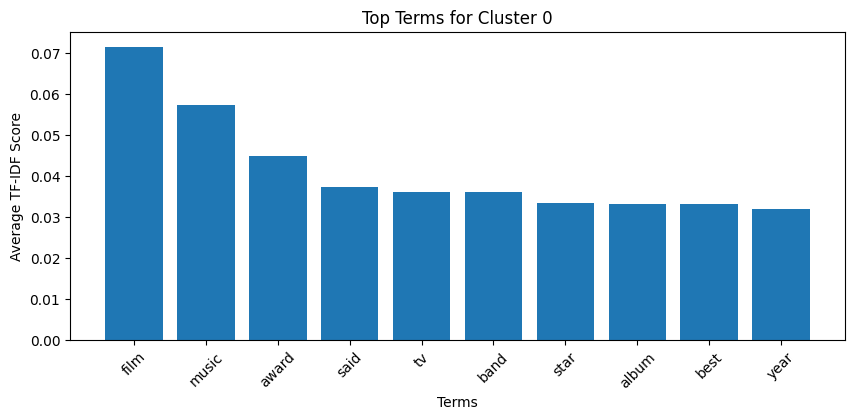

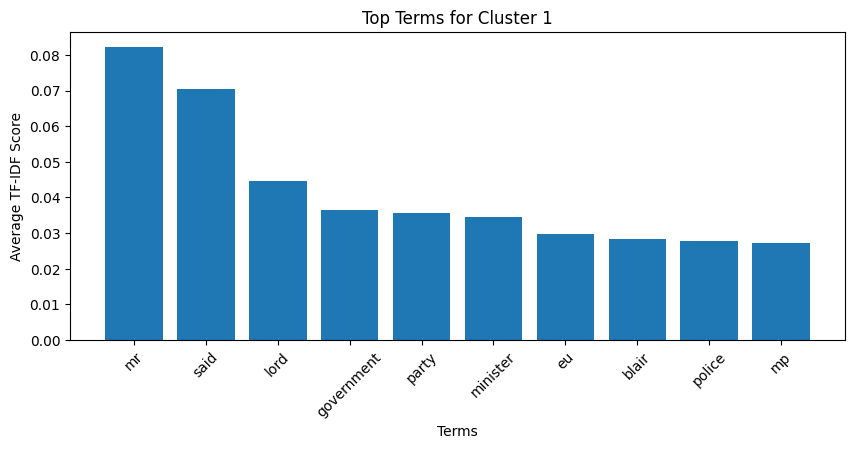

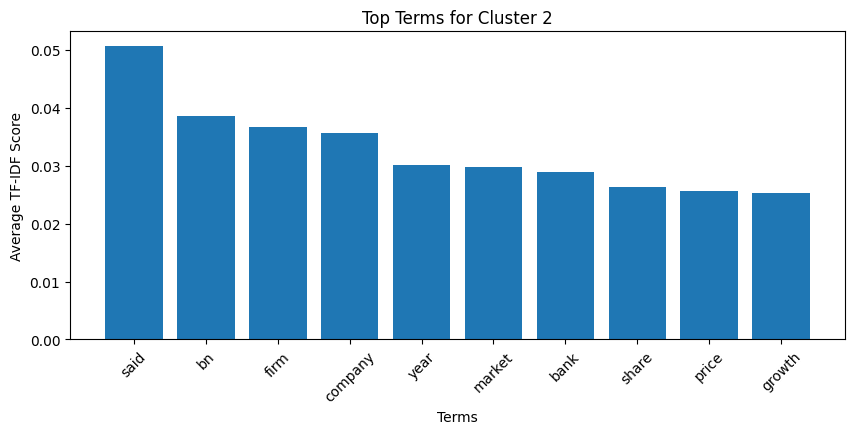

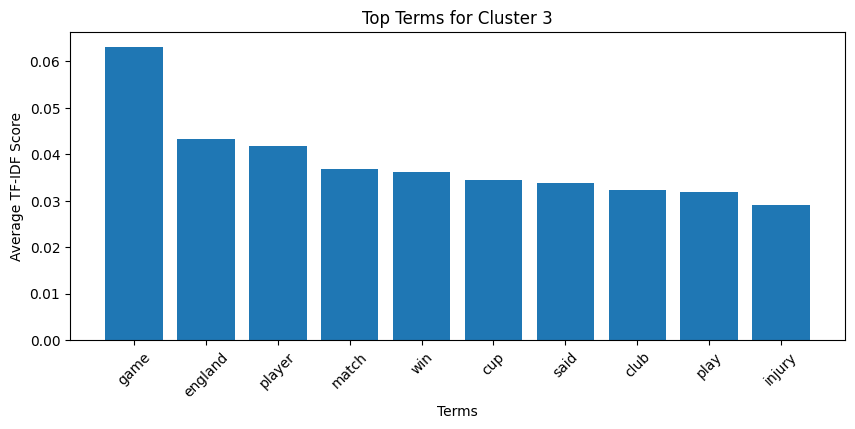

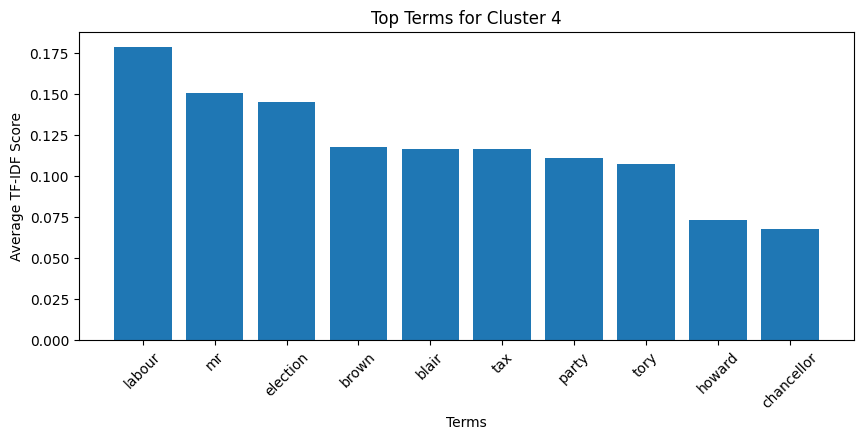

In [32]:
plot_top_terms(kmeans_labels, X, feature_names, 10)


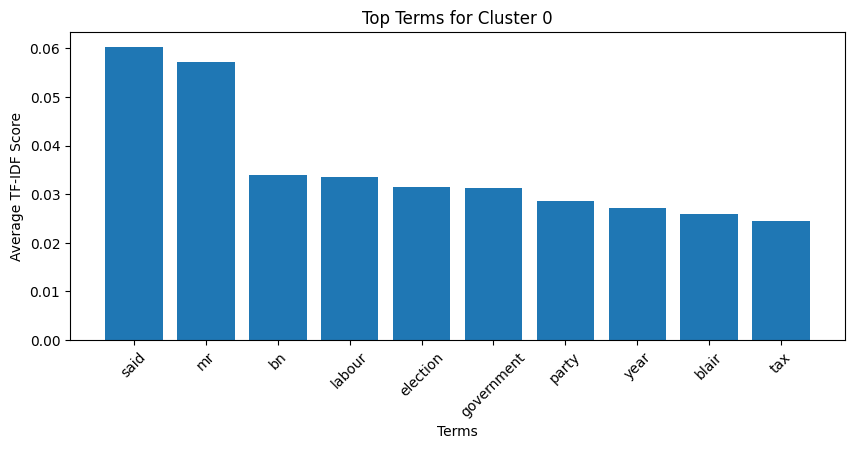

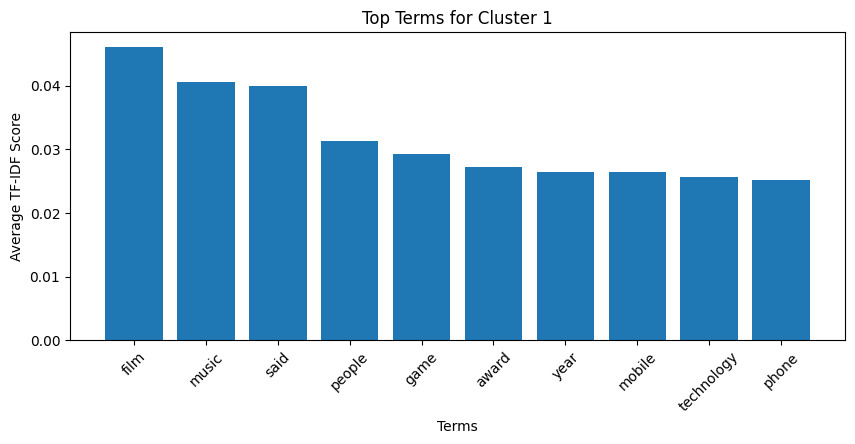

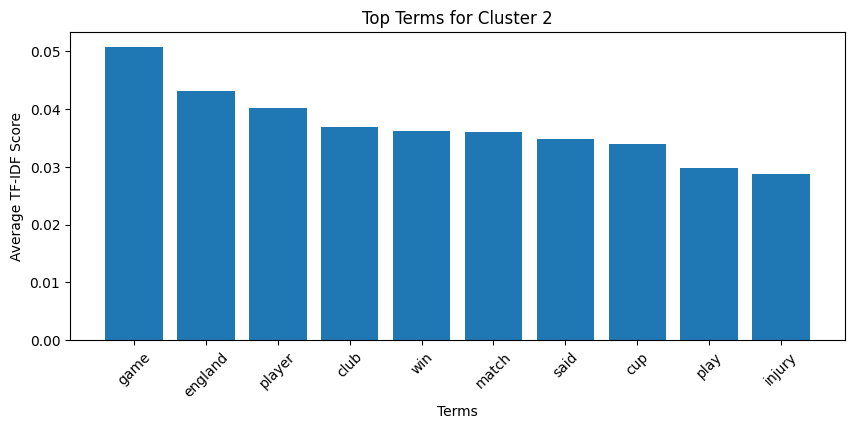

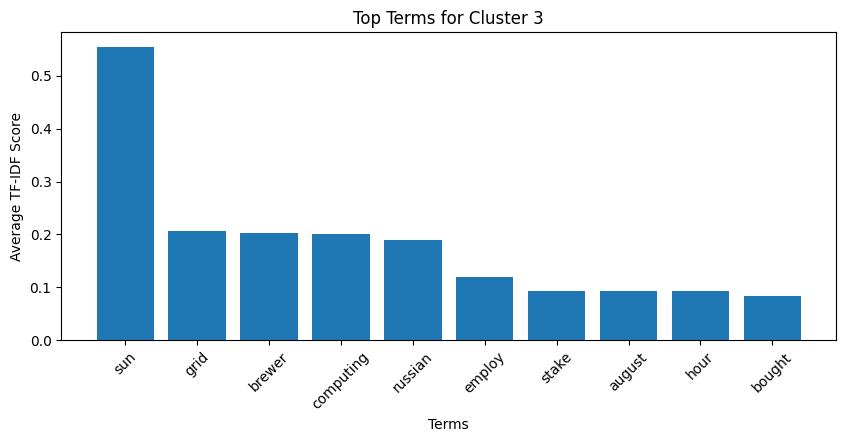

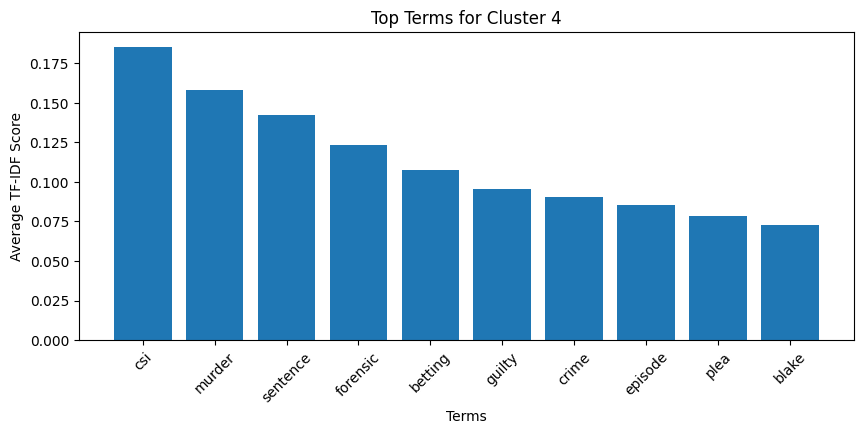

In [33]:
plot_top_terms(agg_labels, X, feature_names, 10)
